In [ ]:
from google.colab import files
uploaded = files.upload()

Saving HR_Data_Analysis_DataSource.xlsx to HR_Data_Analysis_DataSource (3).xlsx


In [ ]:
import pandas as pd
file_path = '/content/HR_Data_Analysis_DataSource.xlsx'
dim_employee = pd.read_excel(file_path, sheet_name='DimEmployee')
dim_department = pd.read_excel(file_path, sheet_name='DimDepartment')
dim_job = pd.read_excel(file_path, sheet_name='DimJobTitle')
dim_location = pd.read_excel(file_path, sheet_name='DimLocation')
dim_recruitment = pd.read_excel(file_path, sheet_name='DimRecruitmentSource')
fact_employee = pd.read_excel(file_path, sheet_name='FactEmployeeDetails')

In [ ]:
print(dim_employee['EmployeeID'].is_unique)
print(dim_department['DepartmentID'].is_unique)
print(dim_job['JobTitleID'].is_unique)
print(dim_location['LocationID'].is_unique)
print(dim_recruitment['RecruitmentSourceID'].is_unique)

True
True
True
True
True


In [ ]:
print(dim_employee.columns)
print(dim_department.columns)
print(dim_job.columns)
print(dim_location.columns)
print(dim_recruitment.columns)
print(fact_employee.columns)

Index(['EmployeeID', 'FirstName', 'LastName', 'Gender', 'DateOfBirth',
       'Nationality', 'MaritalStatus', 'EducationLevel', 'Email',
       'DateOfJoining', 'DateOfLeaving', 'ReasonForLeaving', 'VoluntaryExit',
       'RecruitmentSource', 'TimeToHire', 'CostPerHire'],
      dtype='object')
Index(['DepartmentID', 'DepartmentName'], dtype='object')
Index(['JobTitleID', 'DepartmentID', 'JobTitle', 'PayGrade', 'Level'], dtype='object')
Index(['LocationID', 'Location'], dtype='object')
Index(['RecruitmentSourceID', 'RecruitmentSource'], dtype='object')
Index(['Year', 'EmployeeID', 'DepartmentID', 'JobTitleID', 'LocationID',
       'RecruitmentSourceID', 'HireDate', 'TerminationDate',
       'PerformanceRating', 'BaseSalary', 'Bonus', 'PayGrade',
       'WorkHoursPerWeek', 'OvertimeHours', 'Absences', 'SickLeave',
       'SickLeaveRemain', 'VacationLeave', 'VacationLeaveRemain',
       'LateAttendance', 'EngagementScore', 'SatisfactionScore',
       'ReasonForLeaving', 'VoluntaryExit', '

In [ ]:
dim_job_clean = dim_job.drop(columns=['DepartmentID', 'PayGrade' ])

dim_employee_clean = dim_employee.drop(columns=[
    'RecruitmentSource',
    'TimeToHire',
    'CostPerHire',
    'ReasonForLeaving',
    'VoluntaryExit'
])

In [ ]:
df = fact_employee.merge(
    dim_employee_clean,
    on='EmployeeID',
    how='left'
)

In [ ]:
tables = [
    (dim_job_clean, 'JobTitleID'),
    (dim_department, 'DepartmentID'),
    (dim_recruitment, 'RecruitmentSourceID'),
    (dim_location, 'LocationID')
]

for table, key in tables:
    df = df.merge(table, on=key, how='left')

In [ ]:
print(df.columns)

Index(['Year', 'EmployeeID', 'DepartmentID', 'JobTitleID', 'LocationID',
       'RecruitmentSourceID', 'HireDate', 'TerminationDate',
       'PerformanceRating', 'BaseSalary', 'Bonus', 'PayGrade',
       'WorkHoursPerWeek', 'OvertimeHours', 'Absences', 'SickLeave',
       'SickLeaveRemain', 'VacationLeave', 'VacationLeaveRemain',
       'LateAttendance', 'EngagementScore', 'SatisfactionScore',
       'ReasonForLeaving', 'VoluntaryExit', 'TrainingHours',
       'MandatoryTrainingsAssigned', 'MandatoryTrainingsCompleted',
       'TimeToHire', 'CostPerHire', 'FirstName', 'LastName', 'Gender',
       'DateOfBirth', 'Nationality', 'MaritalStatus', 'EducationLevel',
       'Email', 'DateOfJoining', 'DateOfLeaving', 'JobTitle', 'Level',
       'DepartmentName', 'RecruitmentSource', 'Location'],
      dtype='object')


In [ ]:
print(df['EmployeeID'].nunique())

491


In [ ]:
df.groupby('Gender')['EmployeeID'].nunique()

,EmployeeID
Gender,
F,230
M,261


In [ ]:
top_nationality = dim_employee['Nationality'].value_counts()

print(top_nationality)

Nationality
USA          117
UK            94
Australia     78
Canada        67
Egypt         38
Malaysian     31
Italy         21
France        19
Germany       13
China          9
Turkish        4
Name: count, dtype: int64


Gender
F    230
M    261
Name: EmployeeID, dtype: int64


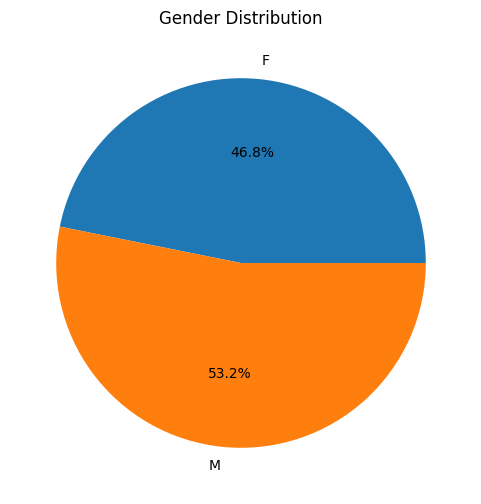

In [ ]:
gender_count = df.groupby('Gender')['EmployeeID'].nunique()

print(gender_count)
gender_count.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title('Gender Distribution')

plt.ylabel('')

plt.show()

In [ ]:
department_count = df.groupby(
    'DepartmentName'
)['EmployeeID'].nunique()

print(department_count)
department_count.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Employees per Department')

plt.xlabel('Department')
plt.ylabel('Unique Employees')
plt.xticks(rotation=45) plt.show()

SyntaxError: invalid syntax (1182840484.py, line 15)

In [ ]:
df['RecruitmentSource']['EmployeeID'].nunique()

KeyError: 'EmployeeID'

In [ ]:
df = fact_employee.merge(
    dim_employee,
    on='EmployeeID',
    how='left'
)

df = df.merge(
    dim_job,
    on='JobTitleID',
    how='left'
)

df = df.merge(
    dim_department,
    on='DepartmentID',
    how='left'
)

df = df.merge(
    dim_recruitment,
    on='RecruitmentSourceID',
    how='left'
)

df = df.merge(
    dim_location,
    on='LocationID',
    how='left'
)

KeyError: 'DepartmentID'

In [ ]:
emp_status = df.sort_values('Year').groupby('EmployeeID').last().reset_index()

In [ ]:
print(df.shape)

(2268, 52)


In [ ]:
print("Total Employees:")
print(df['EmployeeID'].nunique())

Total Employees:
491


In [ ]:
active = df[df['TerminationDate'].isna()]

print("Active Employees:")
print(active['EmployeeID'].nunique())

Active Employees:
468


In [ ]:

terminated = df[df['TerminationDate'].notna()]

print("Terminated Employees:")
print(terminated['EmployeeID'].nunique())

Terminated Employees:
76


In [ ]:
print(df['Gender'].value_counts())

Gender
M    1228
F    1040
Name: count, dtype: int64


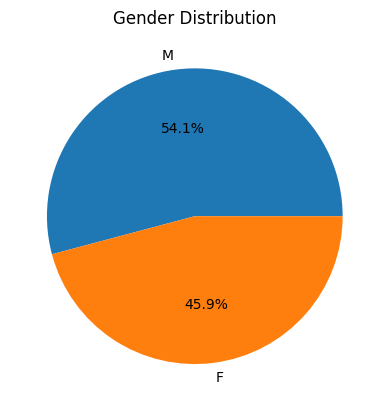

In [ ]:
df['Gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Gender Distribution')
plt.ylabel('')

plt.show()

In [ ]:
top_nationality = df_employees['Nationality'].value_counts()

print(top_nationality)

NameError: name 'df_employees' is not defined

In [ ]:
df['Nationality'].value_counts()

,count
Nationality,
USA,535
UK,399
Australia,338
Canada,309
Egypt,195
Malaysian,158
Italy,108
France,98
Germany,64


In [ ]:
df = df.merge(
    dim_recruitment,
    on='RecruitmentSourceID',
    how='left'
)

In [ ]:
print(df.columns)

Index(['Year', 'EmployeeID', 'DepartmentID_x', 'JobTitleID', 'LocationID',
       'RecruitmentSourceID', 'HireDate', 'TerminationDate',
       'PerformanceRating', 'BaseSalary', 'Bonus', 'PayGrade_x',
       'WorkHoursPerWeek', 'OvertimeHours', 'Absences', 'SickLeave',
       'SickLeaveRemain', 'VacationLeave', 'VacationLeaveRemain',
       'LateAttendance', 'EngagementScore', 'SatisfactionScore',
       'ReasonForLeaving_x', 'VoluntaryExit_x', 'TrainingHours',
       'MandatoryTrainingsAssigned', 'MandatoryTrainingsCompleted',
       'TimeToHire_x', 'CostPerHire_x', 'FirstName', 'LastName', 'Gender',
       'DateOfBirth', 'Nationality', 'MaritalStatus', 'EducationLevel',
       'Email', 'DateOfJoining', 'DateOfLeaving', 'ReasonForLeaving_y',
       'VoluntaryExit_y', 'RecruitmentSource_x', 'TimeToHire_y',
       'CostPerHire_y', 'DepartmentName_x', 'DepartmentName_y',
       'DepartmentID_y', 'JobTitle', 'PayGrade_y', 'Level', 'Location',
       'RecruitmentSource_y'],
      dtype='ob

In [ ]:
df.groupby('DepartmentName_x')['TrainingHours'].mean().sort_values(ascending=False)

,TrainingHours
DepartmentName_x,
Engineering,34.801282
Production,32.356083
Supply Chain,27.393258
Research and Development (R&D),27.380165
Quality Assurance (QA),27.097561
Finance,26.701923
Information Technology (IT),26.247475
Customer Service,25.394191
HR,24.969900


In [ ]:
df = df.loc[:, ~df.columns.duplicated()]

In [ ]:
df['IsActive'] = df['TerminationDate'].isna()

In [ ]:
retention_rate = df['IsActive'].mean() * 100
print("Retention Rate:", retention_rate)

Retention Rate: 96.64902998236332


In [ ]:
df.groupby('IsActive')['TrainingHours'].mean()

,TrainingHours
IsActive,
False,35.500000
True,27.894617


In [ ]:
len(df['EmployeeID'].unique())

491

In [ ]:
df['TerminationDate'].isna().sum()

np.int64(2192)

In [ ]:
df['TerminationDate'].notna().sum()

np.int64(76)

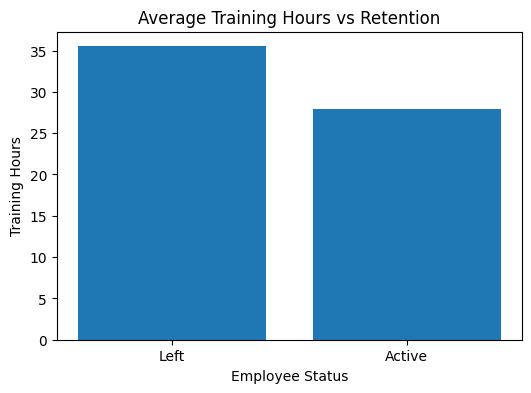

In [ ]:
import matplotlib.pyplot as plt

training_compare = df.groupby('IsActive')['TrainingHours'].mean()

plt.figure(figsize=(6,4))
plt.bar(['Left', 'Active'], training_compare.values)

plt.title('Average Training Hours vs Retention')
plt.xlabel('Employee Status')
plt.ylabel('Training Hours')
plt.show()

In [ ]:
df.groupby(
    'Nationality'
)['EmployeeID'].nunique()

,EmployeeID
Nationality,
Australia,78
Canada,67
China,9
Egypt,38
France,19
Germany,13
Italy,21
Malaysian,31
Turkish,4


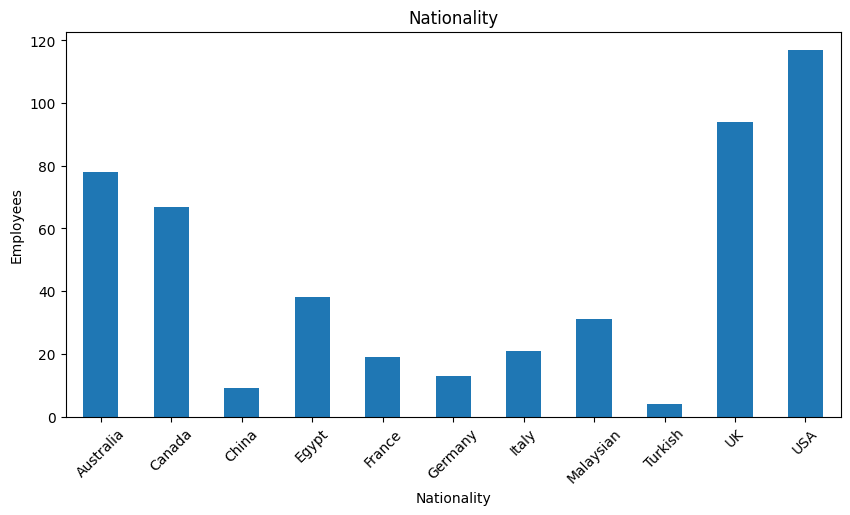

In [ ]:
df.groupby(
    'Nationality'
)['EmployeeID'].nunique().plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Nationality')
plt.xlabel('Nationality')
plt.ylabel('Employees')

plt.xticks(rotation=45)

plt.show()

In [ ]:
df.groupby(
    'DepartmentName'
)['EmployeeID'].nunique()

,EmployeeID
DepartmentName,
Customer Service,50
Engineering,75
Finance,46
HR,60
Information Technology (IT),40
Production,84
Quality Assurance (QA),33
Research and Development (R&D),24
Sales,42


In [ ]:
df.groupby('DepartmentName')['TrainingHours'].mean().sort_values(ascending=False)

,TrainingHours
DepartmentName,
Engineering,34.801282
Production,32.356083
Supply Chain,27.393258
Research and Development (R&D),27.380165
Quality Assurance (QA),27.097561
Finance,26.701923
Information Technology (IT),26.247475
Customer Service,25.394191
HR,24.969900


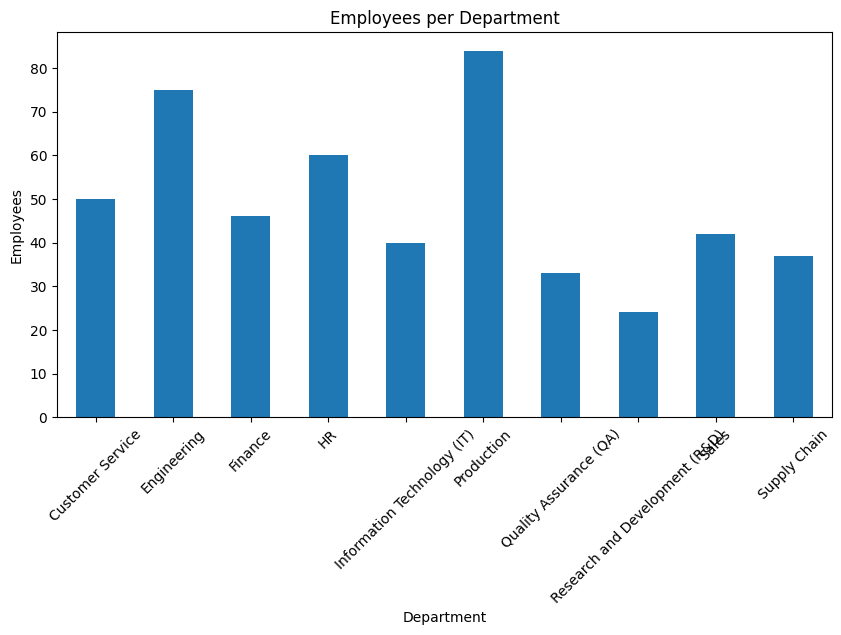

In [ ]:
df.groupby(
    'DepartmentName'
)['EmployeeID'].nunique().plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Employees per Department')
plt.xlabel('Department')
plt.ylabel('Employees')

plt.xticks(rotation=45)

plt.show()

In [ ]:
active = df[df['TerminationDate'].isna()]['EmployeeID'].nunique()

total = df['EmployeeID'].nunique()

retention_rate = (active / total) * 100

print("Retention Rate:")
print(retention_rate)

Retention Rate:
95.31568228105907


In [ ]:
turnover = df[df['TerminationDate'].notna()]

print(turnover['DepartmentName'].value_counts())

DepartmentName
Production                        24
Engineering                       24
HR                                 6
Quality Assurance (QA)             4
Customer Service                   4
Finance                            4
Supply Chain                       3
Information Technology (IT)        3
Sales                              3
Research and Development (R&D)     1
Name: count, dtype: int64


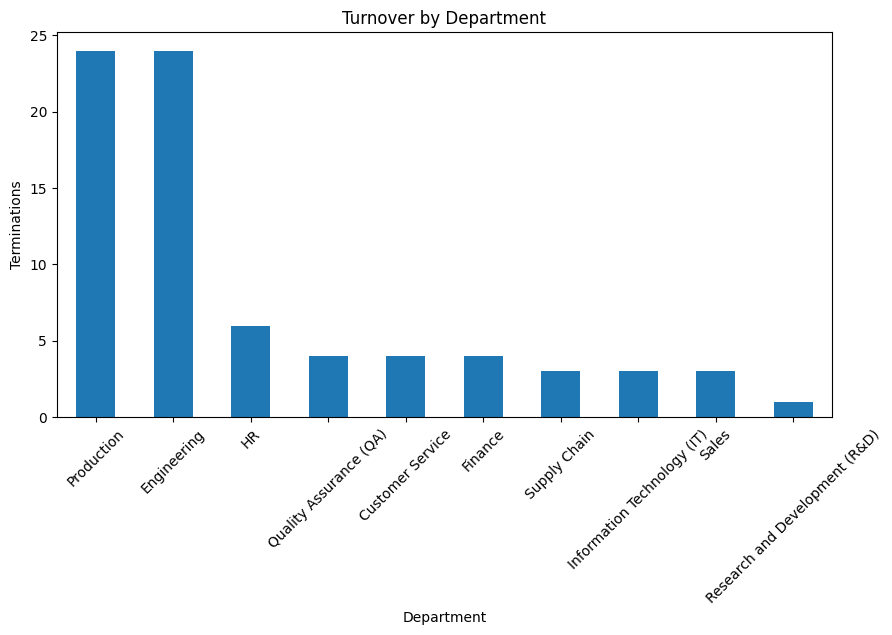

In [ ]:

turnover['DepartmentName'].value_counts().plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Turnover by Department')
plt.xlabel('Department')
plt.ylabel('Terminations')

plt.xticks(rotation=45)

plt.show()

In [ ]:

print("Average Salary:")

print(df['BaseSalary'].mean())

Average Salary:
54797.821869488536


In [ ]:

salary = df.groupby('DepartmentName')['BaseSalary'].mean()

print(salary)

DepartmentName
Customer Service                  42378.091286
Engineering                       60112.708333
Finance                           52081.894231
HR                                45193.501672
Information Technology (IT)       57365.530303
Production                        62535.462908
Quality Assurance (QA)            54228.036585
Research and Development (R&D)    69951.719008
Sales                             48540.676190
Supply Chain                      61704.269663
Name: BaseSalary, dtype: float64


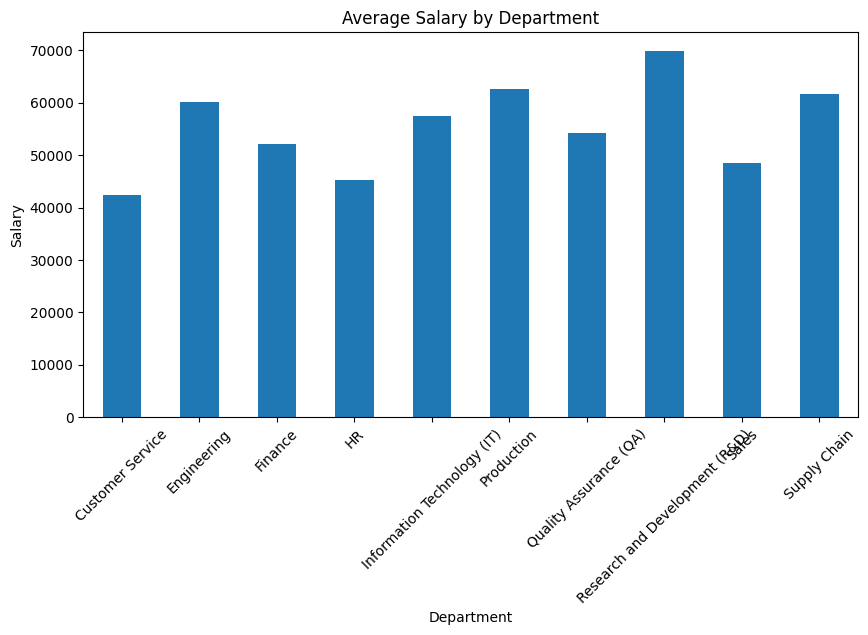

In [ ]:
salary.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Average Salary by Department')
plt.xlabel('Department')
plt.ylabel('Salary')

plt.xticks(rotation=45)

plt.show()

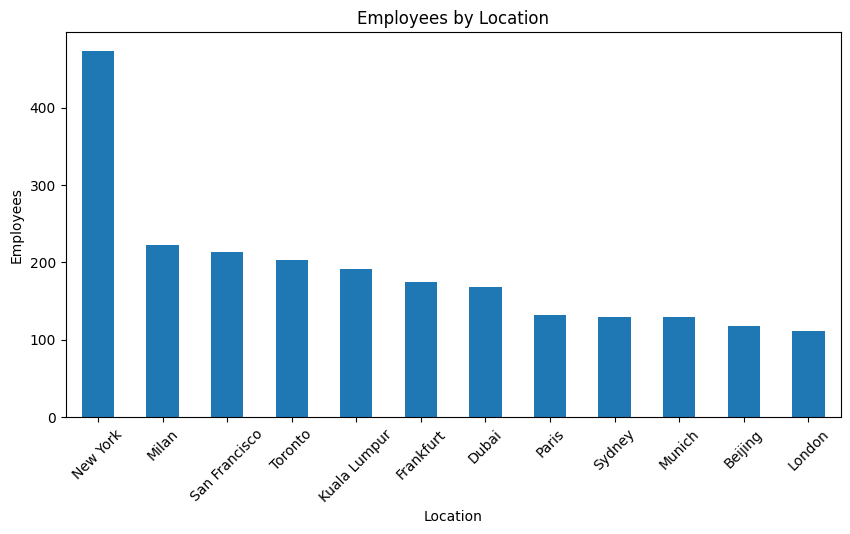

In [ ]:
df['Location'].value_counts().plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Employees by Location')
plt.xlabel('Location')
plt.ylabel('Employees')

plt.xticks(rotation=45)

plt.show()

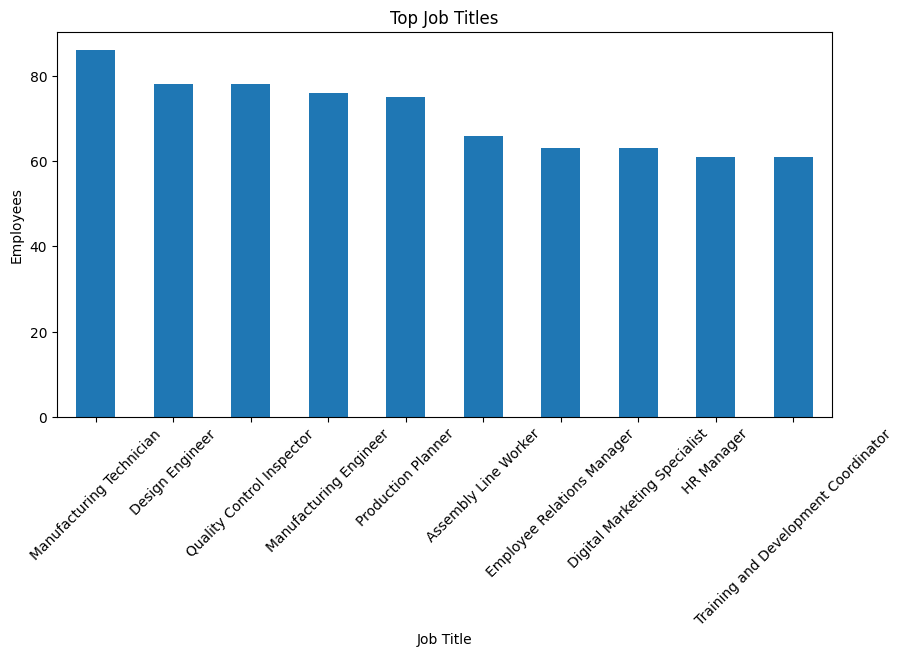

In [ ]:
df['JobTitle'].value_counts().head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top Job Titles')
plt.xlabel('Job Title')
plt.ylabel('Employees')

plt.xticks(rotation=45)

plt.show()

In [ ]:
df['EducationLevel']['EmployeeID'].nunique()



KeyError: 'EmployeeID'

In [ ]:
print(
    df['Nationality'].nunique()
)

11


In [ ]:
print(
    df['DepartmentName'].nunique()
)

10


Object `source` not found.
RecruitmentSource
Referral              8.394737
Direct Application    8.368715
Job Board             8.346856
LinkedIn              8.182432
Name: PerformanceRating, dtype: float64


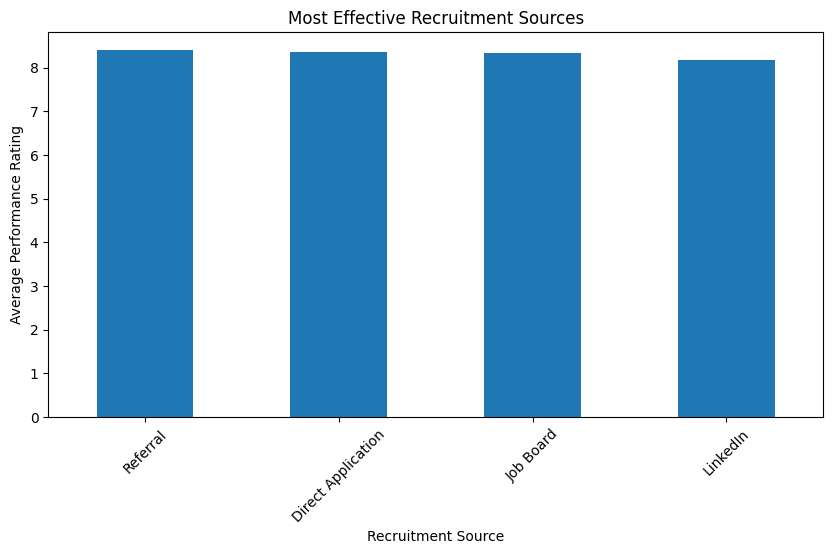

In [ ]:
. What is the most effective recruitment source?
recruitment_effective = df.groupby(
    'RecruitmentSource'
)['PerformanceRating'].mean()

print(recruitment_effective.sort_values(
    ascending=False
))
recruitment_effective.sort_values(
    ascending=False
).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Most Effective Recruitment Sources')

plt.xlabel('Recruitment Source')

plt.ylabel('Average Performance Rating')

plt.xticks(rotation=45)

plt.show()

RecruitmentSource
LinkedIn              145
Direct Application    125
Referral              111
Job Board             110
Name: EmployeeID, dtype: int64


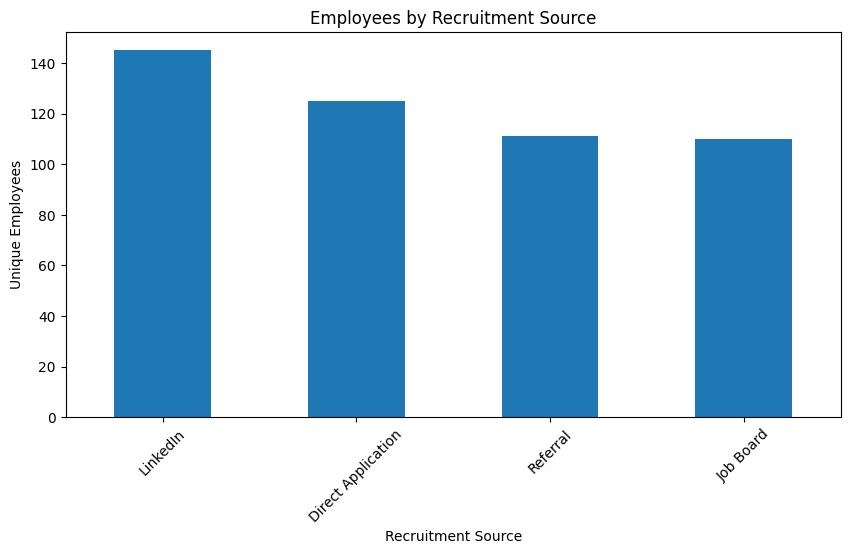

In [ ]:
recruitment_count = df.groupby(
    'RecruitmentSource'
)['EmployeeID'].nunique()

print(recruitment_count.sort_values(
    ascending=False
))
recruitment_count.sort_values(
    ascending=False
).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Employees by Recruitment Source')
plt.xlabel('Recruitment Source')
plt.ylabel('Unique Employees')
plt.xticks(rotation=45)
plt.show()

DepartmentName
Production                        84
Engineering                       75
HR                                60
Customer Service                  50
Finance                           46
Sales                             42
Information Technology (IT)       40
Supply Chain                      37
Quality Assurance (QA)            33
Research and Development (R&D)    24
Name: EmployeeID, dtype: int64


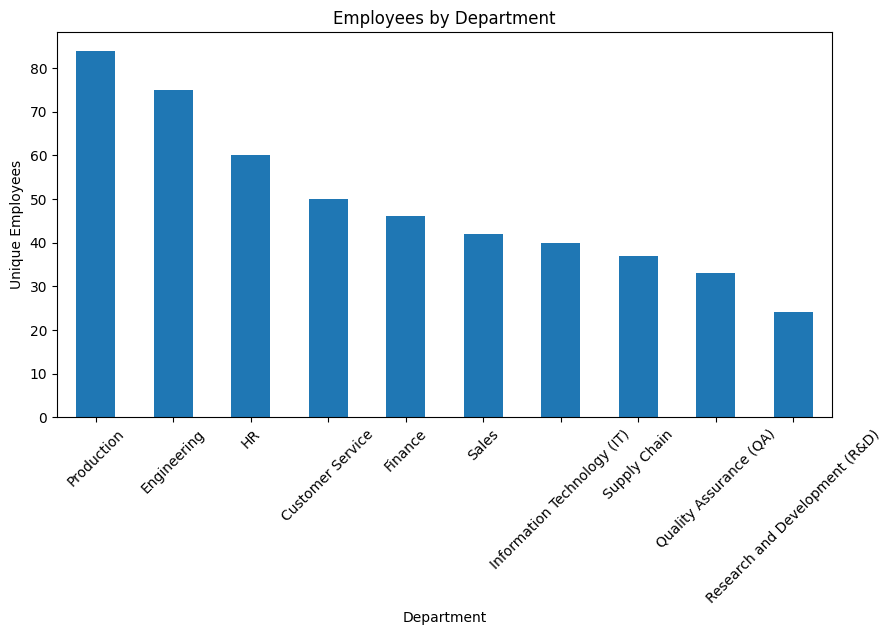

In [ ]:
department_hiring = df.groupby(
    'DepartmentName'
)['EmployeeID'].nunique()

print(
    department_hiring.sort_values(
        ascending=False
    )
)
department_hiring.sort_values(
    ascending=False
).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Employees by Department')

plt.xlabel('Department')

plt.ylabel('Unique Employees')

plt.xticks(rotation=45)

plt.show()

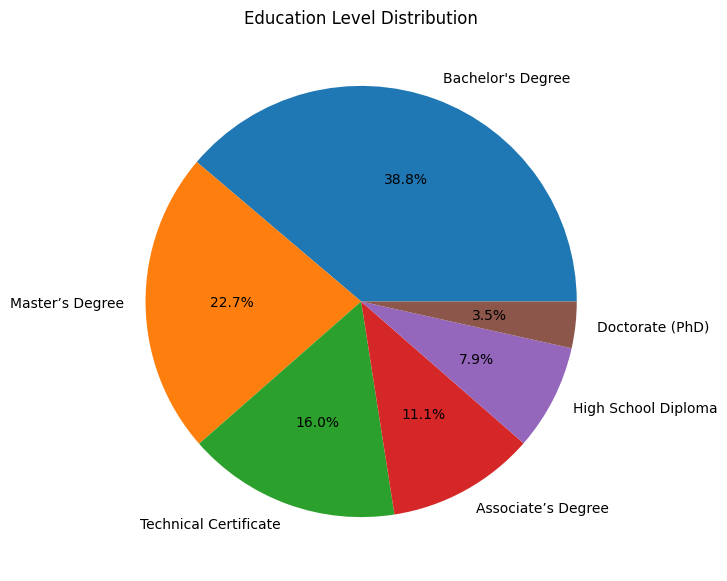

In [ ]:
df['EducationLevel'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7,7)
)

plt.title('Education Level Distribution')
plt.ylabel('')

plt.show()

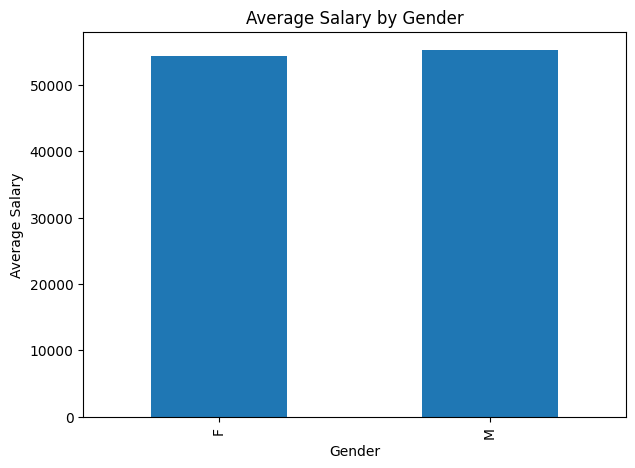

In [ ]:
salary_gender = df.groupby('Gender')['BaseSalary'].mean()

salary_gender.plot(
    kind='bar',
    figsize=(7,5)
)

plt.title('Average Salary by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Salary')

plt.show()

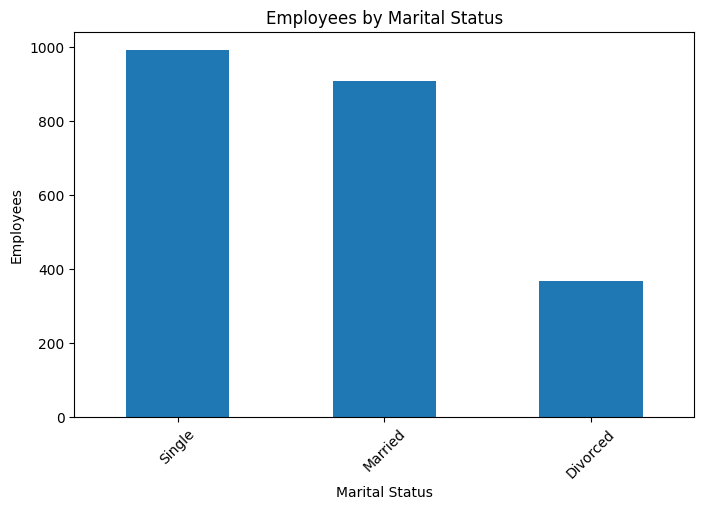

In [ ]:
df['MaritalStatus'].value_counts().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Employees by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Employeesun')

plt.xticks(rotation=45)

plt.show()

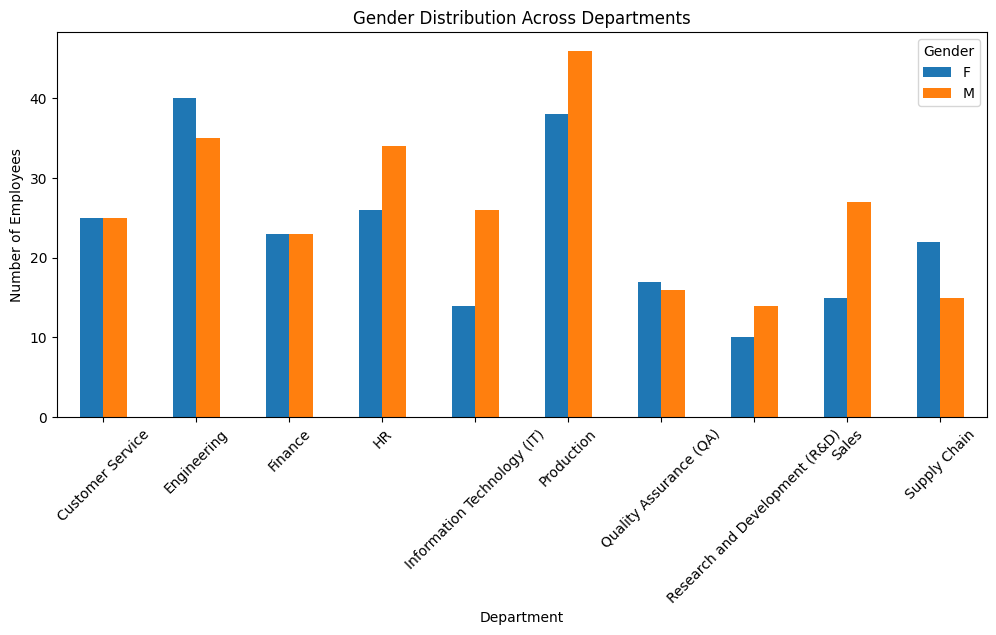

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

gender_dist = pd.crosstab(
    df['DepartmentName'],
    df['Gender'],
    values=df['EmployeeID'],
    aggfunc='nunique'
)

gender_dist.plot(
    kind='bar',
    figsize=(12,5)
)

plt.title('Gender Distribution Across Departments')
plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.xticks(rotation=45)
plt.legend(title='Gender')
plt.show()

In [ ]:
import matplotlib.pyplot as plt

gender_source.plot(
    kind='bar',
    figsize=(12,5)
)

plt.title('Gender Distribution Across Recruitment Sources')
plt.xlabel('Recruitment Source')
plt.ylabel('Number of Employees')
plt.xticks(rotation=45)
plt.legend(title=

SyntaxError: incomplete input (1371671597.py, line 12)

In [ ]:
pd.crosstab(
    df['DepartmentName'],
    df['Gender'],
    values=df['EmployeeID'],
    aggfunc='nunique'
)

Gender,F,M
DepartmentName,,
Customer Service,25,25
Engineering,40,35
Finance,23,23
HR,26,34
Information Technology (IT),14,26
Production,38,46
Quality Assurance (QA),17,16
Research and Development (R&D),10,14
Sales,15,27


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

nationality = pd.crosstab(
    df['Nationality'],
    df['EmployeeID'],
    aggfunc='nunique'
).sort_values(by=df['EmployeeID'].name, ascending=False).head(10)

nationality.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top Nationalities')
plt.xlabel('Nationality')
plt.ylabel('Employees')
plt.xticks(rotation=45)
plt.show()

ValueError: aggfunc cannot be used without values.

In [ ]:
df['Nationality'].value_counts().head(10)


,count
Nationality,
USA,535
UK,399
Australia,338
Canada,309
Egypt,195
Malaysian,158
Italy,108
France,98
Germany,64


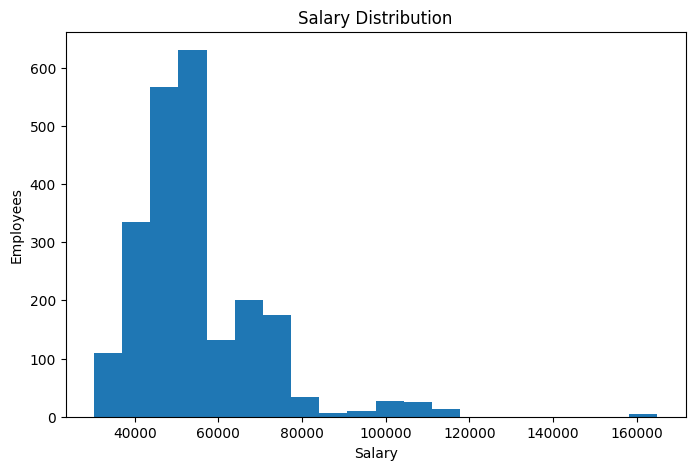

In [ ]:

plt.figure(figsize=(8,5))

plt.hist(df['BaseSalary'], bins=20)

plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Employees')

plt.show()

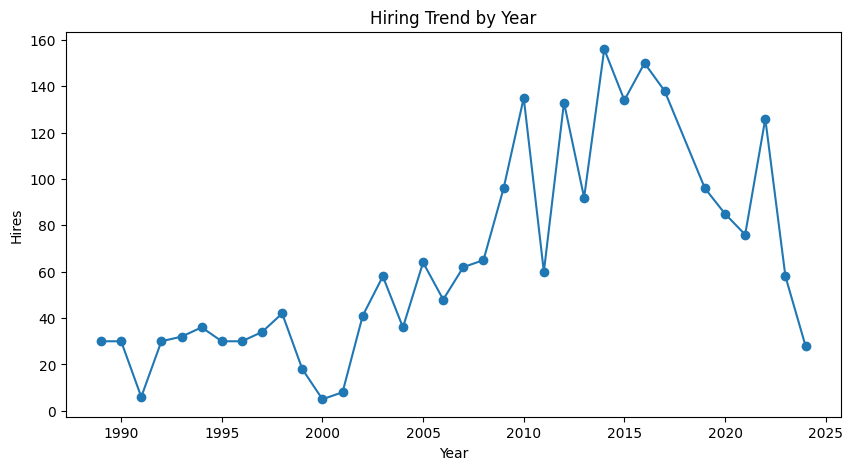

In [ ]:
df['HireYear'] = pd.to_datetime(df['HireDate']).dt.year

df['HireYear'].value_counts().sort_index().plot(
    kind='line',
    marker='o',
    figsize=(10,5)
)

plt.title('Hiring Trend by Year')
plt.xlabel('Year')
plt.ylabel('Hires')

plt.show()

In [ ]:
df['DateOfBirth'] = pd.to_datetime(df['DateOfBirth'])

# Calculate Age

today = pd.to_datetime('today')

df['Age'] = (
    (today - df['DateOfBirth']).dt.days // 365
)

print(df[['DateOfBirth', 'Age']].head())

  DateOfBirth  Age
0  1980-05-17   46
1  1969-04-29   57
2  1997-09-27   28
3  1991-08-01   34
4  1991-04-16   35


In [ ]:
age_group = df['AgeGroup'].value_counts()

plt.figure(figsize=(8,5))

plt.bar(age_group.index.astype(str), age_group.values)

plt.title('Employees by Age Group')

plt.xlabel('Age Group')

plt.ylabel('Number of Employees')

plt.show()

KeyError: 'AgeGroup'

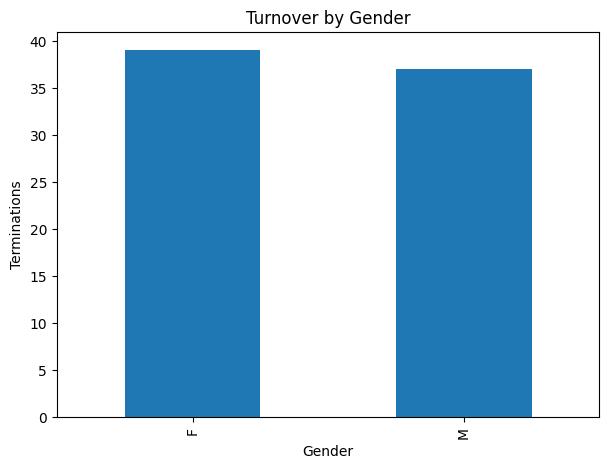

In [ ]:
turnover = df[df['TerminationDate'].notna()]

turnover['Gender'].value_counts().plot(
    kind='bar',
    figsize=(7,5)
)

plt.title('Turnover by Gender')
plt.xlabel('Gender')
plt.ylabel('Terminations')

plt.show()

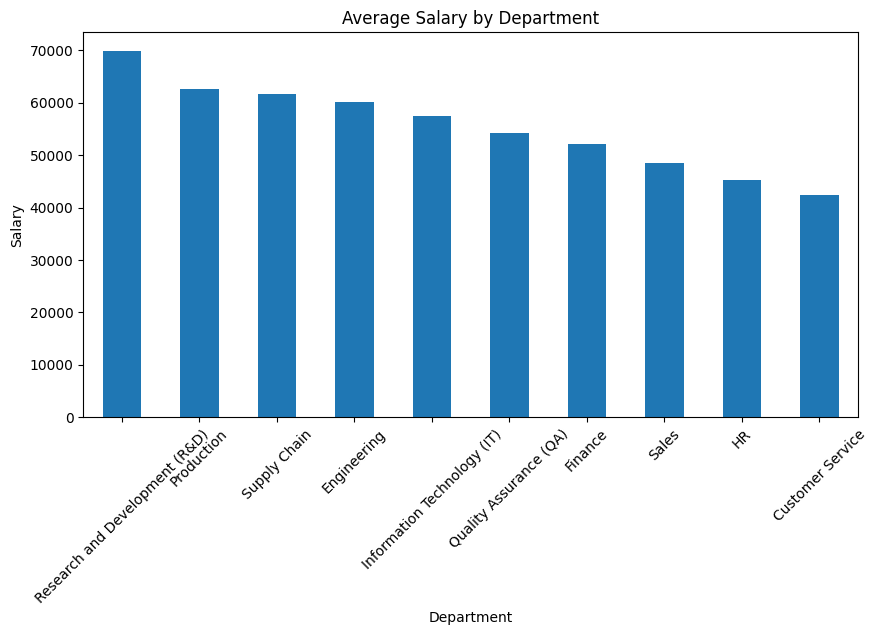

In [ ]:
dept_salary = df.groupby('DepartmentName_y')['BaseSalary'].mean()

dept_salary.sort_values(ascending=False).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Average Salary by Department')
plt.xlabel('Department')
plt.ylabel('Salary')

plt.xticks(rotation=45)

plt.show()

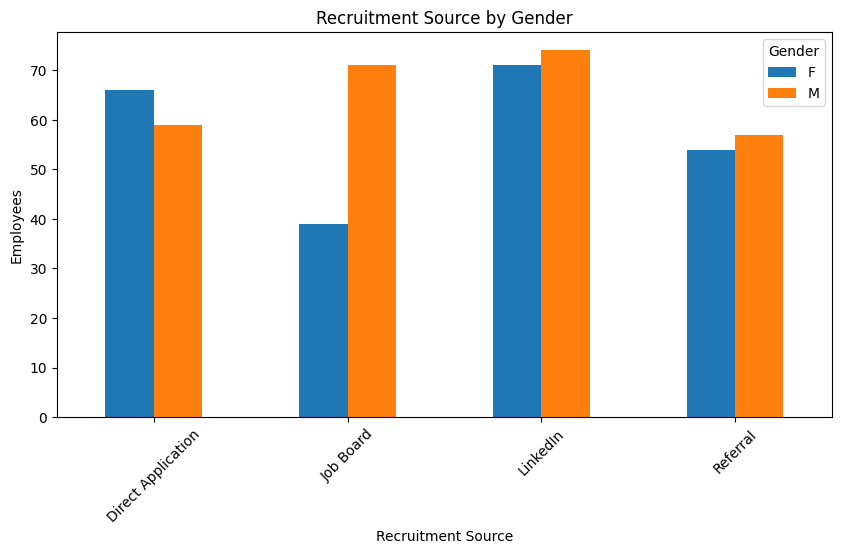

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

gender_source = pd.crosstab(
    df['RecruitmentSource'],
    df['Gender'],
    values=df['EmployeeID'],
    aggfunc='nunique'
)

gender_source.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Recruitment Source by Gender')
plt.xlabel('Recruitment Source')
plt.ylabel('Employees')
plt.xticks(rotation=45)
plt.show()

In [ ]:
import pandas as pd

gender_source = pd.crosstab(
    df['RecruitmentSource'],
    df['Gender'],
    values=df['EmployeeID'],
    aggfunc='nunique'
)

print(gender_source)


Gender               F   M
RecruitmentSource         
Direct Application  66  59
Job Board           39  71
LinkedIn            71  74
Referral            54  57


In [ ]:
education_count = df.groupby(
    'EducationLevel'
)['EmployeeID'].nunique()

print(
    education_count.sort_values(


SyntaxError: incomplete input (526270597.py, line 7)

EducationLevel
Associate’s Degree       50622.162698
Bachelor's Degree        55481.387500
Doctorate (PhD)          63259.797468
High School Diploma      45389.988889
Master’s Degree          61407.229572
Technical Certificate    49504.176309
Name: BaseSalary, dtype: float64


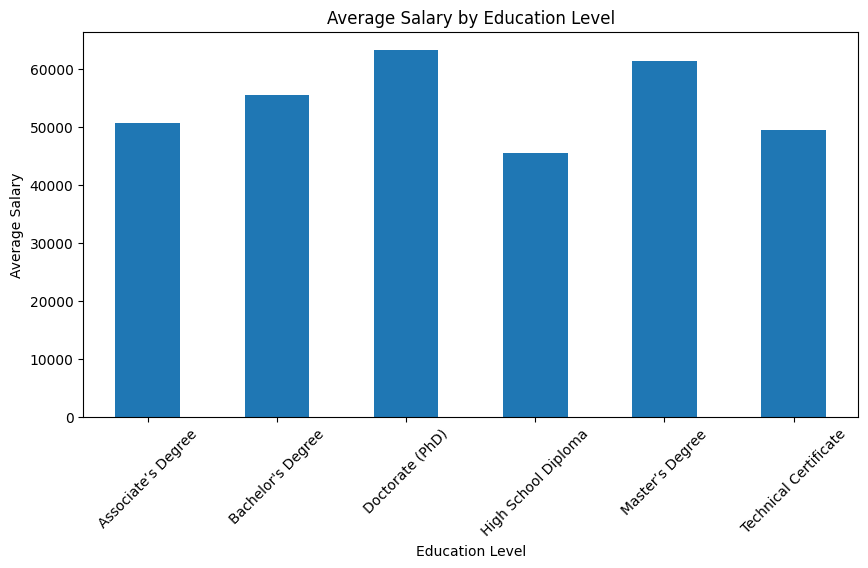

In [ ]:
salary_education = df.groupby(
    'EducationLevel'
)['BaseSalary'].mean()

print(salary_education)
salary_education.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Average Salary by Education Level')

plt.xlabel('Education Level')

plt.ylabel('Average Salary')

plt.xticks(rotation=45)

plt.show()

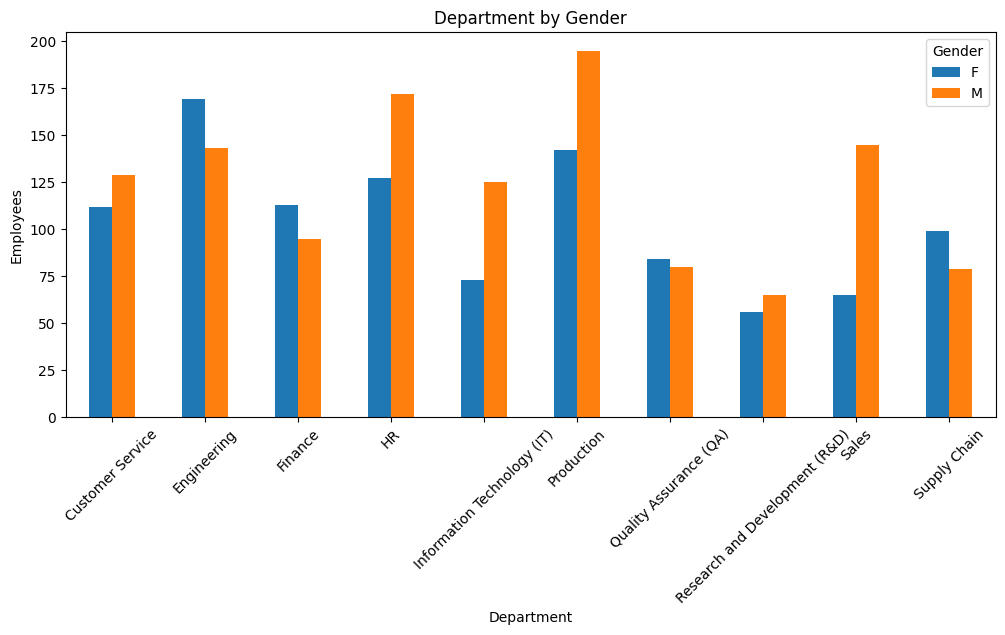

In [ ]:

pd.crosstab(
    df['DepartmentName_x'],
    df['Gender']
).plot(
    kind='bar',
    figsize=(12,5)
)

plt.title('Department by Gender')

plt.xlabel('Department')

plt.ylabel('Employees')

plt.xticks(rotation=45)

plt.show()

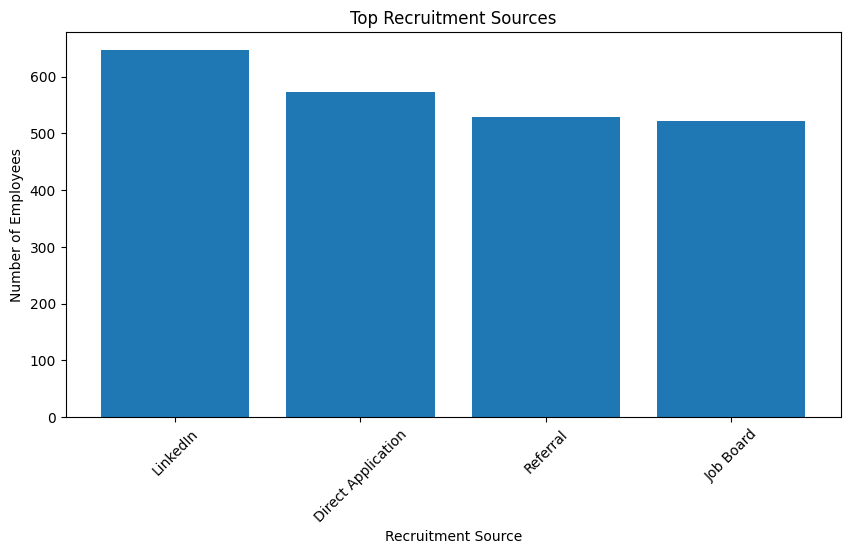

In [ ]:


top_sources = df['RecruitmentSource'].value_counts().head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top_sources.index,
    top_sources.values
)

plt.title('Top Recruitment Sources')

plt.xlabel('Recruitment Source')

plt.ylabel('Number of Employees')

plt.xticks(rotation=45)

plt.show()

([0, 1, 2, 3, 4],
 [Text(0, 0, 'CMO'),
  Text(1, 0, 'CFO'),
  Text(2, 0, 'CIO'),
  Text(3, 0, 'COO'),
  Text(4, 0, 'CEO')])

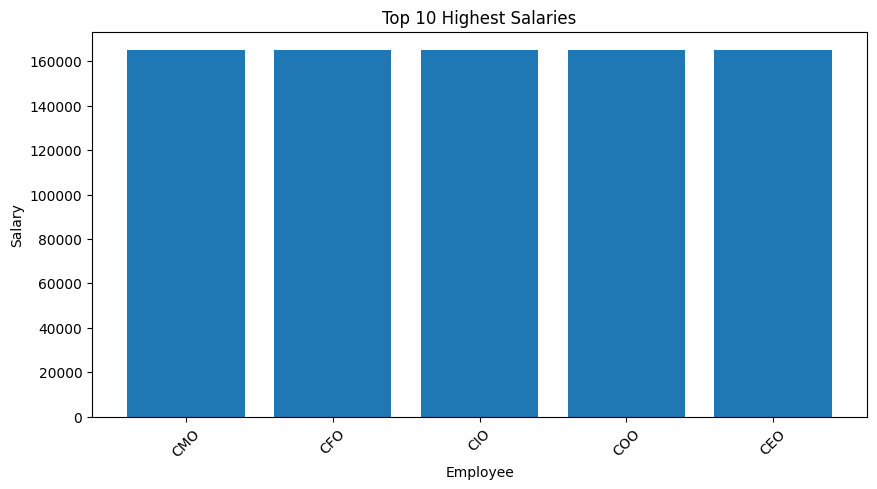

In [ ]:
top_salary = df.nlargest(10, 'BaseSalary')

plt.figure(figsize=(10,5))

plt.bar(
    top_salary['FirstName'],
    top_salary['BaseSalary']
)

plt.title('Top 10 Highest Salaries')
plt.xlabel('Employee')
plt.ylabel('Salary')

plt.xticks(rotation=45)


In [ ]:

df['Nationality']['EmployeeID'].nunique()



KeyError: 'EmployeeID'

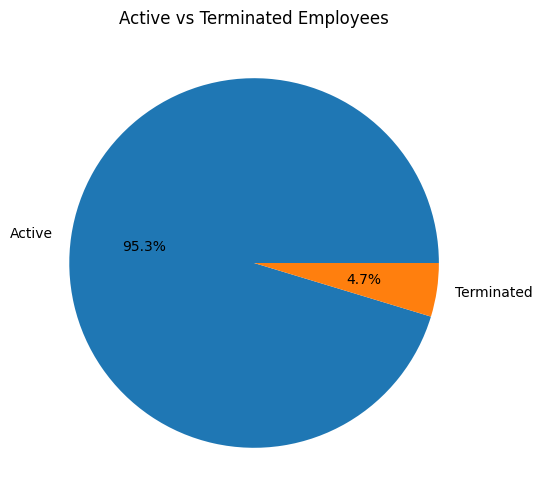

In [ ]:
status_counts = [
    active,
    total - active
]

labels = ['Active', 'Terminated']

plt.figure(figsize=(6,6))

plt.pie(
    status_counts,
    labels=labels,
    autopct='%1.1f%%'
)

plt.title('Active vs Terminated Employees')

plt.show()

In [ ]:
turnover = df[df['TerminationDate'].notna()]

In [ ]:
turnover_source = turnover['RecruitmentSource_y'].value_counts()

print(turnover_source.sort_values())

RecruitmentSource_y
Referral              13
LinkedIn              18
Direct Application    22
Job Board             23
Name: count, dtype: int64


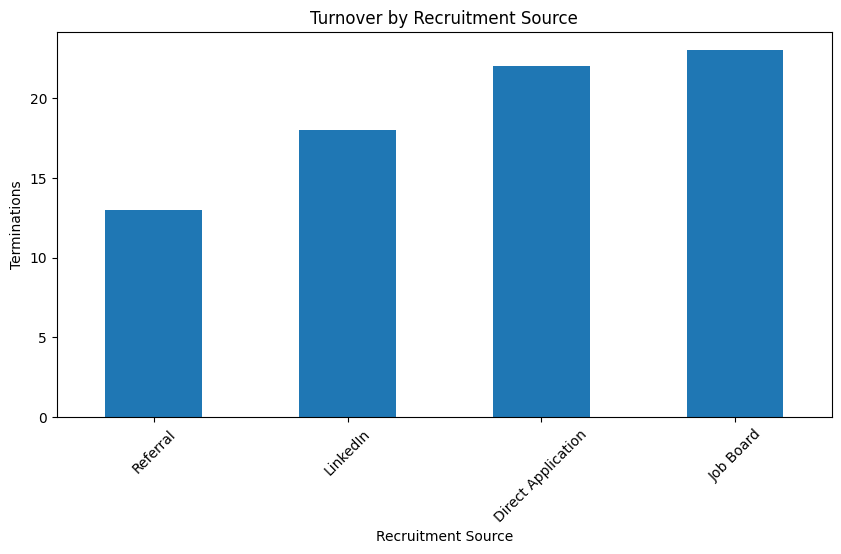

In [ ]:
turnover_source.sort_values().plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Turnover by Recruitment Source')

plt.xlabel('Recruitment Source')

plt.ylabel('Terminations')

plt.xticks(rotation=45)

plt.show()

In [ ]:
df['DateOfBirth'] = pd.to_datetime(df['DateOfBirth'])

# Calculate Age

today = pd.to_datetime('today')

df['Age'] = (
    (today - df['DateOfBirth']).dt.days // 365
)

In [ ]:
bins = [20,30,40,50,60]

labels = ['20-30','31-40','41-50','51-60']

df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)

In [ ]:
age_tenure = df.groupby('AgeGroup')['TenureYears'].mean()

print(age_tenure)

/tmp/ipykernel_13923/2199287777.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_tenure = df.groupby('AgeGroup')['TenureYears'].mean()


KeyError: 'Column not found: TenureYears'

In [ ]:
age_tenure.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Average Tenure by Age Group')

plt.xlabel('Age Group')

plt.ylabel('Average Years')

plt.xticks(rotation=0)

plt.show()

NameError: name 'age_tenure' is not defined

AgeGroup
20-30    141
31-40    128
41-50    104
51-60    101
Name: EmployeeID, dtype: int64


/tmp/ipykernel_13923/3561401352.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group = df.groupby(


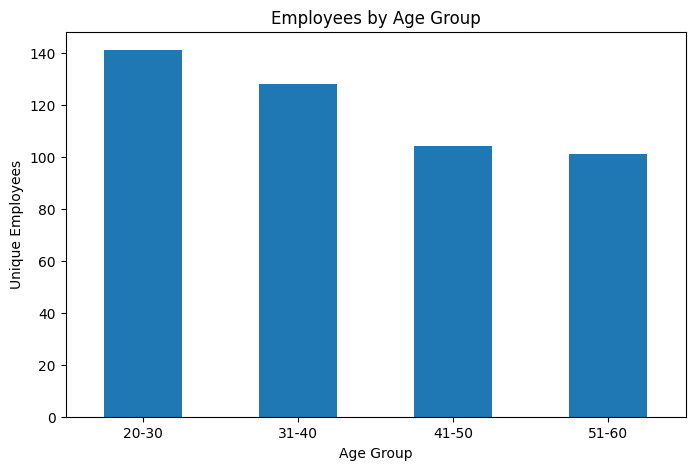

In [ ]:
df['DateOfBirth'] = pd.to_datetime(
    df['DateOfBirth']
)

today = pd.to_datetime('today')

df['Age'] = (
    (today - df['DateOfBirth']).dt.days // 365
)

bins = [20,30,40,50,60]

labels = [
    '20-30',
    '31-40',
    '41-50',
    '51-60'
]

df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)

age_group = df.groupby(
    'AgeGroup'
)['EmployeeID'].nunique()

print(age_group)
age_group.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Employees by Age Group')

plt.xlabel('Age Group')

plt.ylabel('Unique Employees')

plt.xticks(rotation=0)

plt.show()

In [ ]:
active_df = df[df['TerminationDate'].isna()]

In [ ]:
import pandas as pd

active_df['DateOfBirth'] = pd.to_datetime(active_df['DateOfBirth'])

today = pd.to_datetime('today')

active_df['Age'] = (
    (today - active_df['DateOfBirth']).dt.days // 365
)

/tmp/ipykernel_13923/1679307842.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  active_df['DateOfBirth'] = pd.to_datetime(active_df['DateOfBirth'])
/tmp/ipykernel_13923/1679307842.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  active_df['Age'] = (


In [ ]:
active_df = df[df['TerminationDate'].isna()].copy()

In [ ]:
active_df = df[df['TerminationDate'].isna()].copy()

active_df['DateOfBirth'] = pd.to_datetime(active_df['DateOfBirth'])

today = pd.to_datetime('today')

active_df['Age'] = (
    (today - active_df['DateOfBirth']).dt.days // 365
)

print(active_df[['EmployeeID', 'Age']])

      EmployeeID  Age
0         110001   46
1         110002   57
2         110003   28
3         110004   34
4         110005   35
...          ...  ...
2263      110471   65
2264      110475   58
2265      110480   63
2266      110482   64
2267      110484   67

[2192 rows x 2 columns]


In [ ]:
active_df = df[df['Attrition'] == 'No']

KeyError: 'Attrition'

Object `company` not found.


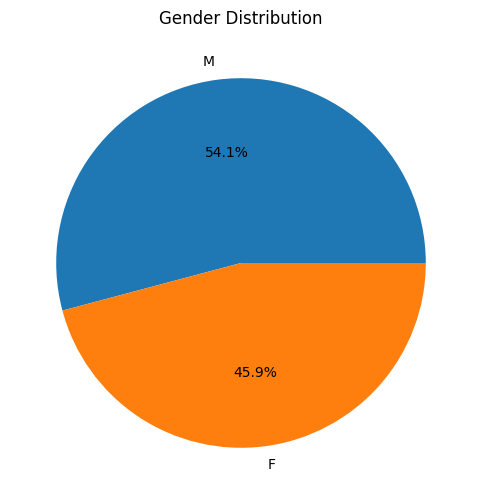

In [ ]:
What is the gender distribution in the company?

df['Gender'].value_counts()
df['Gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title('Gender Distribution')

plt.ylabel('')

plt.show()

In [ ]:
turnover = df[df['TerminationDate'].notna()] \
    .groupby('DepartmentName')['EmployeeID'] \
    .nunique() \
    .sort_values(ascending=False)

print(turnover)

DepartmentName
Engineering                       24
Production                        24
HR                                 6
Customer Service                   4
Finance                            4
Quality Assurance (QA)             4
Information Technology (IT)        3
Sales                              3
Supply Chain                       3
Research and Development (R&D)     1
Name: EmployeeID, dtype: int64


In [ ]:
emp_status = df.sort_values('Year').groupby('EmployeeID').last().reset_index()

In [ ]:
emp_status['IsActive'] = emp_status['TerminationDate'].isna()

In [ ]:
active_count = emp_status['IsActive'].sum()

print("Active Employees:", active_count)

Active Employees: 415


In [ ]:
active_count = emp_status['IsActive'].sum()

print("Active Employees:", active_count)

Active Employees: 415


In [ ]:
active_count = emp_status['IsActive'].sum()

print("Active Employees:", active_count)

Active Employees: 415


In [ ]:
total_employees = emp_status['EmployeeID'].nunique()

print("Total Employees:", total_employees)

Total Employees: 491


In [ ]:
retention_rate = (active_count / total_employees) * 100

print("Retention Rate:", retention_rate)

Retention Rate: 84.5213849287169


In [ ]:
emp = df.sort_values('Year').groupby('EmployeeID').last().reset_index()

In [ ]:
emp['IsActive'] = emp['TerminationDate'].isna()

In [ ]:
emp.groupby('IsActive')['TrainingHours'].mean()

,TrainingHours
IsActive,
False,35.50000
True,36.26747


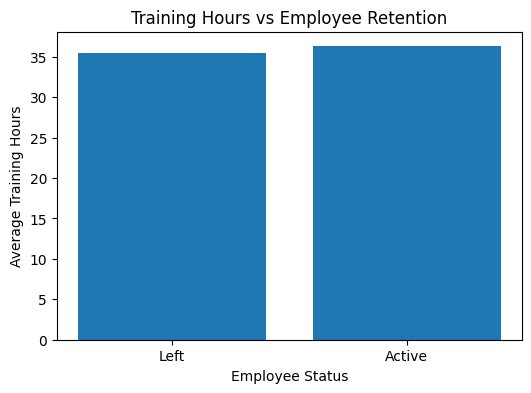

In [ ]:
import matplotlib.pyplot as plt

training_compare = emp.groupby('IsActive')['TrainingHours'].mean()

plt.figure(figsize=(6,4))
plt.bar(['Left', 'Active'], training_compare.values)

plt.title('Training Hours vs Employee Retention')
plt.xlabel('Employee Status')
plt.ylabel('Average Training Hours')
plt.show()

In [ ]:
emp['TrainingLevel'] = pd.cut(
    emp['TrainingHours'],
    bins=[0, 10, 20, 50, 100],
    labels=['Low', 'Medium', 'High', 'Very High']
)

emp.groupby('TrainingLevel')['IsActive'].mean() * 100

/tmp/ipykernel_13923/1680673671.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  emp.groupby('TrainingLevel')['IsActive'].mean() * 100


,IsActive
TrainingLevel,
Low,92.000000
Medium,84.507042
High,80.514706
Very High,91.836735


In [ ]:
import pandas as pd
import numpy as np
emp = df.sort_values('Year').groupby('EmployeeID').last().reset_index()
emp['IsActive'] = emp['TerminationDate'].isna()
emp['TrainingCategory'] = np.where(
    emp['TrainingHours'] < 10, 'Low Training',
    np.where(
        emp['TrainingHours'] <= 20, 'Medium Training',
        'High Training'
    )
)
training_analysis = emp.groupby('TrainingCategory').agg(
    TotalEmployees=('EmployeeID', 'nunique'),
    RetentionRate=('IsActive', 'mean')
)

training_analysis['RetentionRate'] = (
    training_analysis['RetentionRate'] * 100
).round(2)
print(training_analysis)

                  TotalEmployees  RetentionRate
TrainingCategory                               
High Training                370          83.51
Low Training                  37          91.89
Medium Training               84          85.71


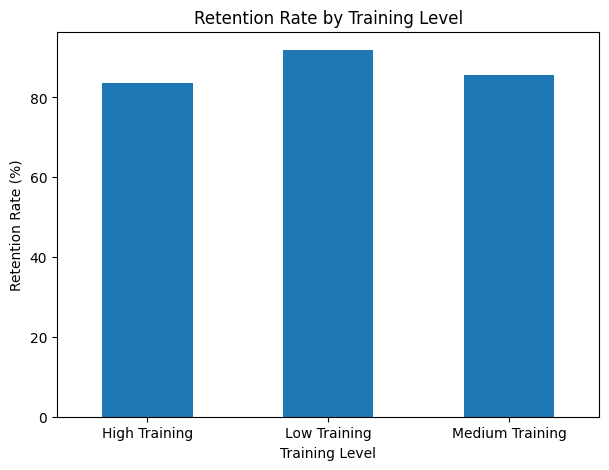

In [ ]:
import matplotlib.pyplot as plt

training_analysis['RetentionRate'].plot(
    kind='bar',
    figsize=(7,5)
)

plt.title('Retention Rate by Training Level')
plt.xlabel('Training Level')
plt.ylabel('Retention Rate (%)')
plt.xticks(rotation=0)
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# Employee-level data
emp = df.sort_values('Year').groupby('EmployeeID').last().reset_index()

# Active employees
emp['IsActive'] = emp['TerminationDate'].isna()

# Salary categories
emp['SalaryCategory'] = np.where(
    emp['BaseSalary'] < 40000, 'Low Salary',
    np.where(
        emp['BaseSalary'] <= 70000, 'Mid Salary',
        'High Salary'
    )
)

# Analysis
salary_analysis = emp.groupby('SalaryCategory').agg(
    TotalEmployees=('EmployeeID', 'nunique'),
    RetentionRate=('IsActive', 'mean')
)

# Convert to percentage
salary_analysis['RetentionRate'] = (
    salary_analysis['RetentionRate'] * 100
).round(2)

print(salary_analysis)

                TotalEmployees  RetentionRate
SalaryCategory                               
High Salary                 94          93.62
Low Salary                  23          82.61
Mid Salary                 374          82.35


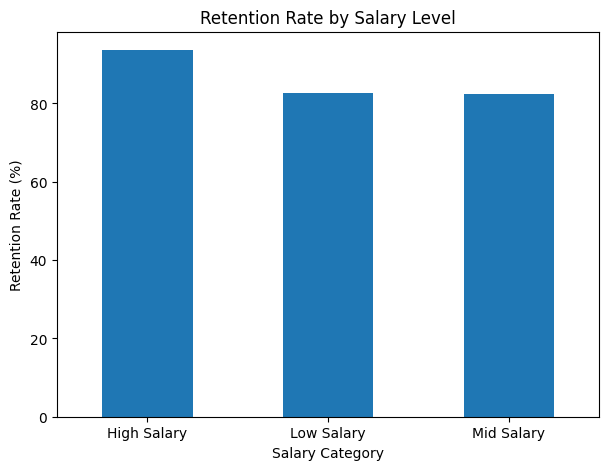

In [ ]:
import matplotlib.pyplot as plt

salary_analysis['RetentionRate'].plot(
    kind='bar',
    figsize=(7,5)
)

plt.title('Retention Rate by Salary Level')
plt.xlabel('Salary Category')
plt.ylabel('Retention Rate (%)')
plt.xticks(rotation=0)
plt.show()

In [ ]:
avg_salary_year = df.groupby('Year')['BaseSalary'].mean()

print(avg_salary_year)

Year
2019    52497.630682
2020    53344.303977
2021    54450.048159
2022    55063.879896
2023    55460.268657
2024    57323.328638
Name: BaseSalary, dtype: float64
